# Deck Archetype Trends

Track curated Deck archetypes, team switching, and field matchups across configurable calendar-day replay snapshots. Run `deck/trend_extract.py` before this notebook.

## Goal

This baseline uses only the project's ordered `ARCHETYPE_RULES`. Every unmatched 60-card Deck is grouped into `Other`; fallback main-Pokemon labels are intentionally disabled.

## Setup and Configuration

In [47]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml


def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        direct = candidate
        nested = candidate / 'imitation_learning'
        if (direct / 'deck' / 'trend.py').is_file():
            return direct
        if (nested / 'deck' / 'trend.py').is_file():
            return nested
    raise FileNotFoundError('Could not locate imitation_learning project root')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from deck.analysis import CardCatalog
from deck.trend import (
    add_trend_archetypes,
    build_daily_metrics,
    build_matchups,
    build_pooled_archetype_shares,
    build_team_flows,
    build_team_modal_archetypes,
    daily_share_visibility,
    parse_month_day,
    plot_archetype_sankey,
    select_snapshot_dates,
)

CONFIG_PATH = PROJECT_ROOT / 'cfg' / 'deck_trend.yaml'
CARD_DATA_PATH = PROJECT_ROOT.parent / 'pokemon_tcg_ai_battle' / 'EN_Card_Data.csv'
config = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
extract_cfg = config['extract']
analysis_cfg = config['analysis']

SNAPSHOT_INTERVAL_DAYS = int(analysis_cfg['snapshot_interval_days'])
START_DATE = analysis_cfg.get('start_date')
END_DATE = analysis_cfg.get('end_date')
MIN_SHARE_PERCENT = float(analysis_cfg['min_share_percent'])
if type(analysis_cfg['snapshot_interval_days']) is not int:
    raise ValueError('analysis.snapshot_interval_days must be an integer')
if type(analysis_cfg['exclude_mirror_matches']) is not bool:
    raise ValueError('analysis.exclude_mirror_matches must be true or false')
EXCLUDE_MIRROR_MATCHES = analysis_cfg['exclude_mirror_matches']

if SNAPSHOT_INTERVAL_DAYS < 1:
    raise ValueError('analysis.snapshot_interval_days must be >= 1')
if MIN_SHARE_PERCENT < 0 or MIN_SHARE_PERCENT > 100:
    raise ValueError('analysis.min_share_percent must be in [0, 100]')

data_dir = Path(extract_cfg['output'])
if not data_dir.is_absolute():
    data_dir = PROJECT_ROOT / data_dir
analysis_dir = data_dir / 'analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Config:', CONFIG_PATH)
print('Data:', data_dir)
print('Interval days:', SNAPSHOT_INTERVAL_DAYS)
print('Date bounds:', START_DATE, END_DATE)
print('Minimum displayed share:', MIN_SHARE_PERCENT)

Config: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\cfg\deck_trend.yaml
Data: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend
Interval days: 1
Date bounds: 8.11 8.14
Minimum displayed share: 1.0


## Load and Validate Extracted Data

In [48]:
shard_paths = list(data_dir.glob('*.players.csv.gz'))
if not shard_paths:
    raise FileNotFoundError(
        f'No trend shards found in {data_dir}. Run deck/trend_extract.py first.'
    )
shard_paths.sort(key=lambda path: parse_month_day(path.name.split('.players.csv.gz')[0]))
player_rows = pd.concat(
    [pd.read_csv(path, dtype={'date': str, 'episode_id': str}) for path in shard_paths],
    ignore_index=True,
)
required_columns = {
    'date', 'episode_id', 'player', 'team_name', 'opponent_team_name',
    'deck', 'reward', 'result',
}
missing = required_columns - set(player_rows.columns)
if missing:
    raise ValueError(f'Extracted rows are missing columns: {sorted(missing)}')

pair_sizes = player_rows.groupby(['date', 'episode_id']).size()
assert pair_sizes.eq(2).all(), 'Every replay must have exactly two player rows'
assert player_rows.groupby(['date', 'episode_id'])['player'].apply(
    lambda values: set(values.astype(int)) == {0, 1}
).all(), 'Every replay must contain player indices 0 and 1'
assert player_rows['team_name'].astype(str).str.strip().ne('').all()
assert player_rows['deck'].map(lambda value: len(json.loads(value)) == 60).all()

print(f'Shards: {len(shard_paths):,}')
print(f'Games: {len(player_rows) // 2:,}')
print(f'Player rows: {len(player_rows):,}')
print(f'Unique teams: {player_rows.team_name.nunique():,}')

Shards: 50
Games: 242,895
Player rows: 485,790
Unique teams: 2,049


## Select Date Snapshots

In [49]:
snapshot_dates = select_snapshot_dates(
    player_rows['date'].unique(),
    SNAPSHOT_INTERVAL_DAYS,
    start_date=START_DATE,
    end_date=END_DATE,
)
if not snapshot_dates:
    raise ValueError('No available dates remain after applying the analysis settings')
selected_rows = player_rows[player_rows['date'].isin(snapshot_dates)].copy()
selected_rows['date'] = pd.Categorical(
    selected_rows['date'], categories=snapshot_dates, ordered=True
)
pd.DataFrame({'date': snapshot_dates}).to_csv(
    analysis_dir / 'snapshot_dates.csv', index=False, encoding='utf-8-sig'
)
print('Selected snapshots:', snapshot_dates)
display(selected_rows.groupby('date', observed=True).agg(
    games=('episode_id', lambda values: values.nunique()),
    teams=('team_name', 'nunique'),
).reset_index())

Selected snapshots: ['8.11', '8.12', '8.13', '8.14']


,date,games,teams
0,8.11,4622,377
1,8.12,4604,394
2,8.13,4615,370
3,8.14,4447,374


## Classification Coverage

In [50]:
catalog = CardCatalog.from_csv(CARD_DATA_PATH)
annotated = add_trend_archetypes(selected_rows, catalog)
annotated['date'] = pd.Categorical(
    annotated['date'].astype(str), categories=snapshot_dates, ordered=True
)
coverage = (
    annotated.assign(matched=lambda frame: frame['archetype'].ne('Other'))
    .groupby('date', observed=True)
    .agg(
        player_rows=('archetype', 'size'),
        curated_rows=('matched', 'sum'),
        unique_teams=('team_name', 'nunique'),
    )
    .reset_index()
)
coverage['curated_percent'] = 100 * coverage['curated_rows'] / coverage['player_rows']
coverage['other_percent'] = 100 - coverage['curated_percent']
display(coverage)

,date,player_rows,curated_rows,unique_teams,curated_percent,other_percent
0,8.11,9244,8765,377,94.818260,5.181740
1,8.12,9208,8643,394,93.864031,6.135969
2,8.13,9230,8584,370,93.001083,6.998917
3,8.14,8894,8555,374,96.188442,3.811558


## Archetype Usage and Win Rate

In [51]:
daily_metrics = build_daily_metrics(
    annotated, exclude_mirrors=EXCLUDE_MIRROR_MATCHES
)
daily_metrics['date'] = pd.Categorical(
    daily_metrics['date'].astype(str), categories=snapshot_dates, ordered=True
)
assert np.allclose(
    daily_metrics.groupby('date', observed=True)['share_percent'].sum().to_numpy(),
    100.0,
)
assert daily_metrics['non_mirror_win_rate'].dropna().between(0, 1).all()
daily_visible_mask = daily_share_visibility(
    daily_metrics, MIN_SHARE_PERCENT
)
daily_visible_archetypes = set(
    daily_metrics.loc[daily_visible_mask, 'archetype']
)
pooled_archetype_shares = build_pooled_archetype_shares(daily_metrics)
global_visible_archetypes = set(
    pooled_archetype_shares.loc[
        pooled_archetype_shares['share_percent'] >= MIN_SHARE_PERCENT,
        'archetype',
    ]
)
daily_metrics.to_csv(
    analysis_dir / 'archetype_daily_metrics.csv', index=False, encoding='utf-8-sig'
)
display(daily_metrics.sort_values(['date', 'uses'], ascending=[True, False]))

,date,archetype,uses,share_percent,wins,losses,draws,non_mirror_games,non_mirror_win_rate
0,8.11,Marnie Grimmsnarl,2120,22.933795,647,969,0,1616,0.400371
1,8.11,Alakazam,1589,17.189528,638,713,0,1351,0.472243
2,8.11,Dragapult,1286,13.911727,660,428,0,1088,0.606618
3,8.11,Mega Froslass,1239,13.403289,567,506,0,1073,0.528425
4,8.11,Festival Lead,829,8.967979,411,344,0,755,0.544371
...,...,...,...,...,...,...,...,...,...
58,8.14,Cynthia Garchomp,36,0.404767,15,19,0,34,0.441176
59,8.14,Team Rocket Mewtwo,23,0.258601,9,14,0,23,0.391304
60,8.14,N's Zoroark,22,0.247358,14,8,0,22,0.636364
61,8.14,Chandelure,2,0.022487,2,0,0,2,1.000000


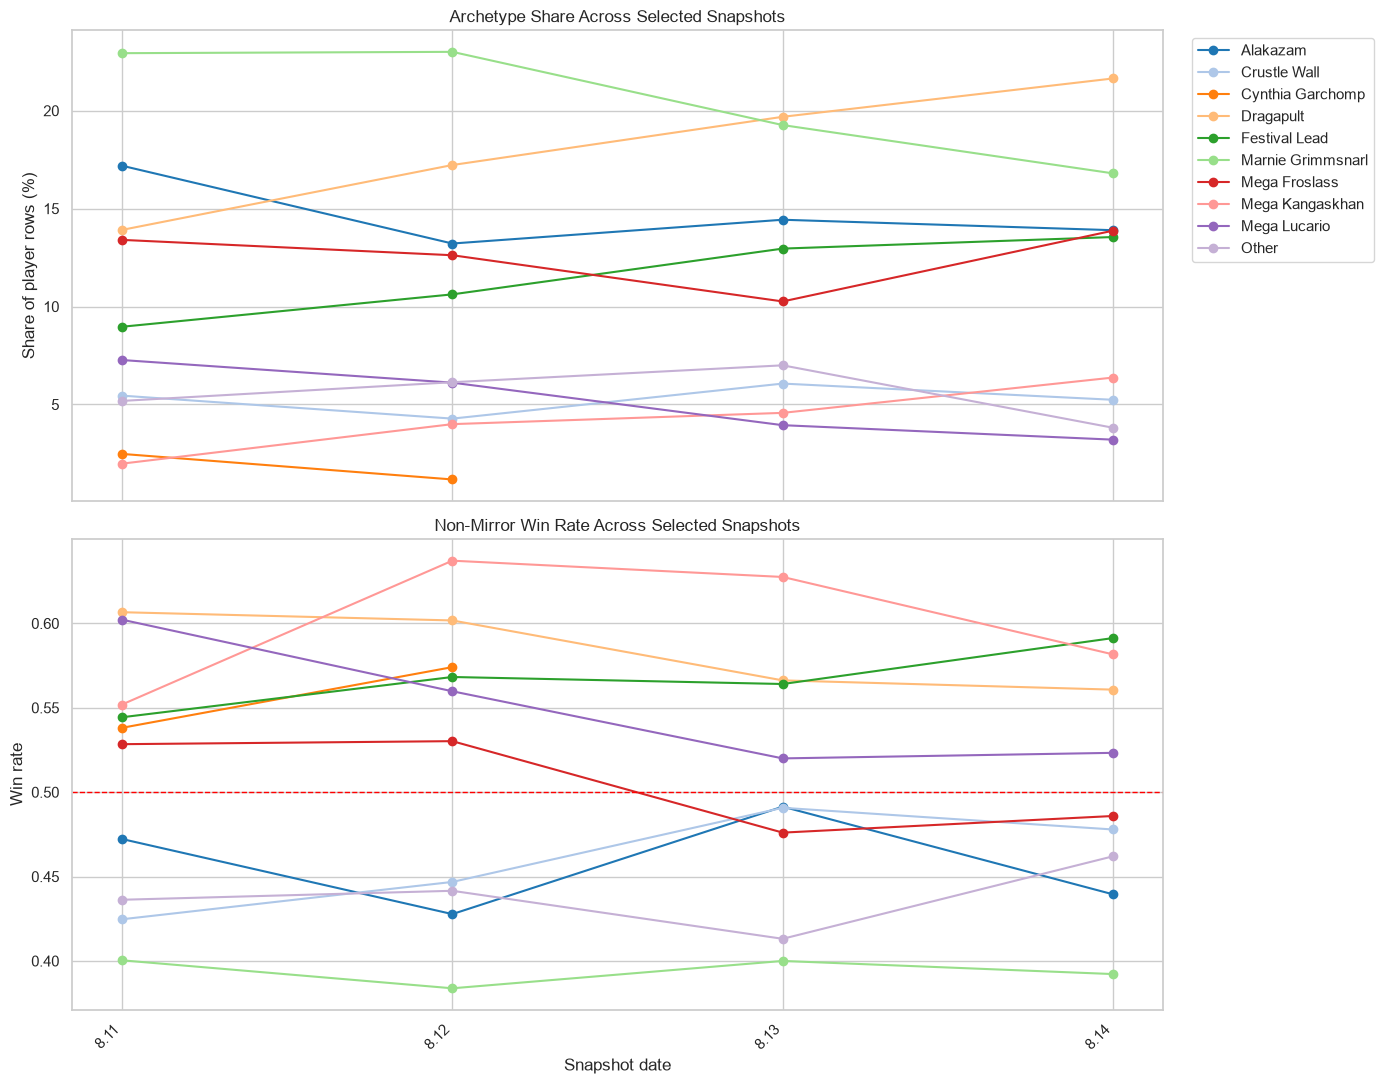

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
date_positions = np.arange(len(snapshot_dates))
line_archetypes = sorted(daily_visible_archetypes)
line_colors = dict(zip(
    line_archetypes, sns.color_palette('tab20', n_colors=len(line_archetypes))
))
for archetype in line_archetypes:
    series = daily_metrics[daily_metrics['archetype'] == archetype].copy()
    series['date'] = series['date'].astype(str)
    series = series.set_index('date').reindex(snapshot_dates)
    visible = series['share_percent'].ge(MIN_SHARE_PERCENT)
    axes[0].plot(
        date_positions, series['share_percent'].where(visible),
        marker='o', linewidth=1.5, label=archetype,
        color=line_colors[archetype],
    )
    axes[1].plot(
        date_positions, series['non_mirror_win_rate'].where(visible),
        marker='o', linewidth=1.5, color=line_colors[archetype],
    )
axes[0].set_title('Archetype Share Across Selected Snapshots')
axes[0].set_ylabel('Share of player rows (%)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Non-Mirror Win Rate Across Selected Snapshots')
axes[1].set_ylabel('Win rate')
axes[1].set_xlabel('Snapshot date')
axes[1].set_xticks(date_positions, snapshot_dates, rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Team Modal Archetypes and Retention

In [53]:
team_modal = build_team_modal_archetypes(annotated)
team_flows, team_retention = build_team_flows(team_modal, snapshot_dates)
team_modal.to_csv(
    analysis_dir / 'team_modal_archetypes.csv', index=False, encoding='utf-8-sig'
)
team_flows.to_csv(
    analysis_dir / 'team_snapshot_flows.csv', index=False, encoding='utf-8-sig'
)
team_retention.to_csv(
    analysis_dir / 'team_retention.csv', index=False, encoding='utf-8-sig'
)
switched_flows = team_flows[
    team_flows['source_archetype'] != team_flows['target_archetype']
]
inflow = switched_flows.groupby('target_archetype')['teams'].sum().rename('inflow')
outflow = switched_flows.groupby('source_archetype')['teams'].sum().rename('outflow')
flow_balance = pd.concat([inflow, outflow], axis=1).fillna(0).astype(int)
flow_balance['net_flow'] = flow_balance['inflow'] - flow_balance['outflow']
display(team_retention)
display(flow_balance.sort_values('net_flow', ascending=False))
display(team_flows.sort_values('teams', ascending=False).head(30))

,from_date,to_date,from_teams,to_teams,overlapping_teams,from_retention_rate,to_retention_rate,unchanged_teams,switched_teams,switch_rate
0,8.11,8.12,377,394,275,0.729443,0.697970,226,49,0.178182
1,8.12,8.13,394,370,274,0.695431,0.740541,222,52,0.189781
2,8.13,8.14,370,374,255,0.689189,0.681818,205,50,0.196078


,inflow,outflow,net_flow
Dragapult,33,19,14
Festival Lead,19,12,7
Mega Froslass,19,15,4
Other,8,6,2
N's Zoroark,2,1,1
Mega Kangaskhan,6,6,0
Crustle Wall,11,12,-1
Mega Lucario,11,12,-1
Team Rocket Mewtwo,0,2,-2
Cynthia Garchomp,4,6,-2


,from_date,to_date,source_archetype,target_archetype,teams
32,8.11,8.12,Marnie Grimmsnarl,Marnie Grimmsnarl,80
75,8.12,8.13,Marnie Grimmsnarl,Marnie Grimmsnarl,79
126,8.13,8.14,Marnie Grimmsnarl,Marnie Grimmsnarl,60
0,8.11,8.12,Alakazam,Alakazam,41
99,8.13,8.14,Alakazam,Alakazam,39
50,8.12,8.13,Alakazam,Alakazam,37
82,8.12,8.13,Mega Froslass,Mega Froslass,24
133,8.13,8.14,Mega Froslass,Mega Froslass,23
96,8.12,8.13,Other,Other,22
113,8.13,8.14,Dragapult,Dragapult,22


## Sankey Flow

In [54]:
%pip install -U "nbformat>=4.2.0"

Note: you may need to restart the kernel to use updated packages.


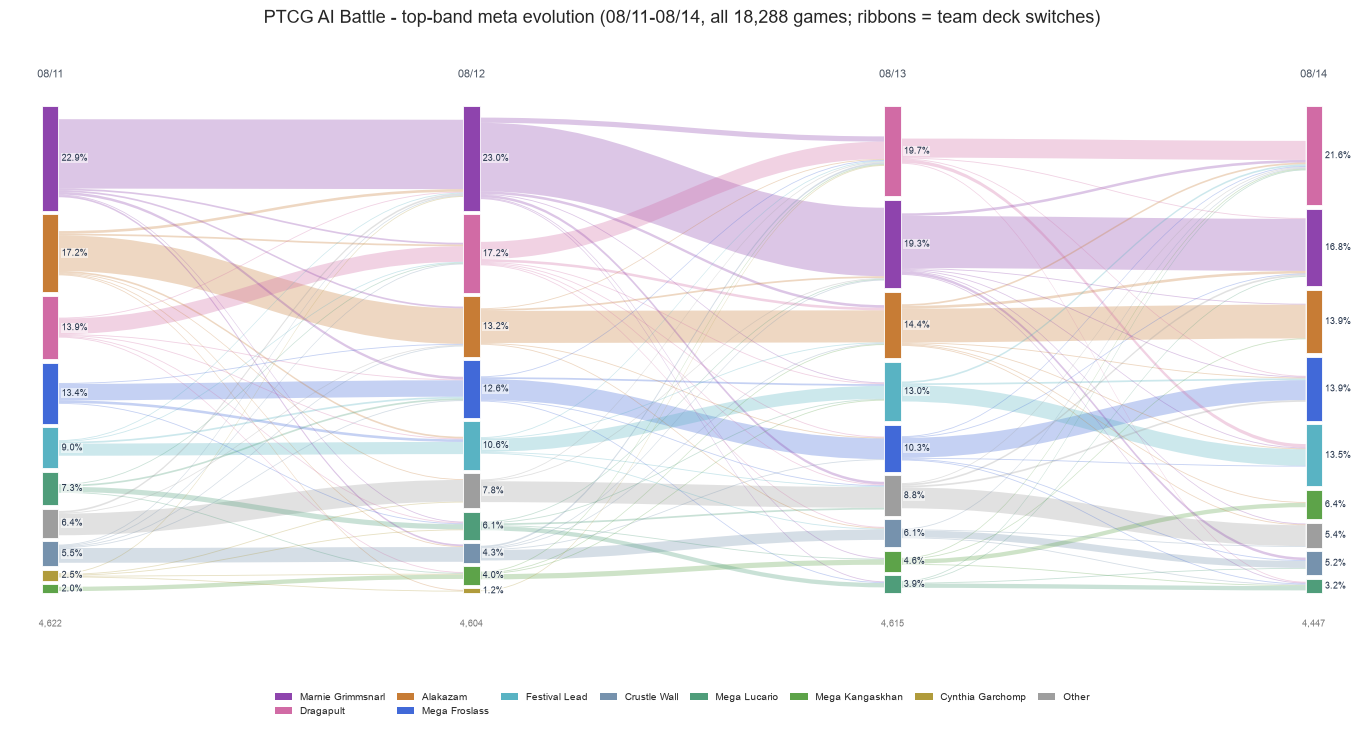

Saved: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend\analysis\archetype_sankey.png


In [55]:
share_lookup = daily_metrics.set_index(['date', 'archetype'])['share_percent'].to_dict()
display_rows = annotated[['date', 'archetype']].copy()
display_rows['display_archetype'] = display_rows.apply(
    lambda row: row['archetype']
    if share_lookup.get((row['date'], row['archetype']), 0) >= MIN_SHARE_PERCENT
    else 'Other',
    axis=1,
)
display_shares = (
    display_rows.groupby(['date', 'display_archetype'], observed=True).size()
    .rename('uses').reset_index()
)
display_shares['share_percent'] = 100 * display_shares['uses'] / (
    display_shares.groupby('date', observed=True)['uses'].transform('sum')
)
display_modal = team_modal.copy()
display_modal['display_archetype'] = display_modal.apply(
    lambda row: row['modal_archetype']
    if share_lookup.get((row['date'], row['modal_archetype']), 0) >= MIN_SHARE_PERCENT
    else 'Other',
    axis=1,
)
display_modal = display_modal.drop(columns='modal_archetype').rename(
    columns={'display_archetype': 'modal_archetype'}
)
display_flows, _ = build_team_flows(display_modal, snapshot_dates)

sankey_figure = plot_archetype_sankey(
    display_shares, display_flows, snapshot_dates
)
sankey_path = analysis_dir / 'archetype_sankey.png'
sankey_figure.savefig(sankey_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', sankey_path)

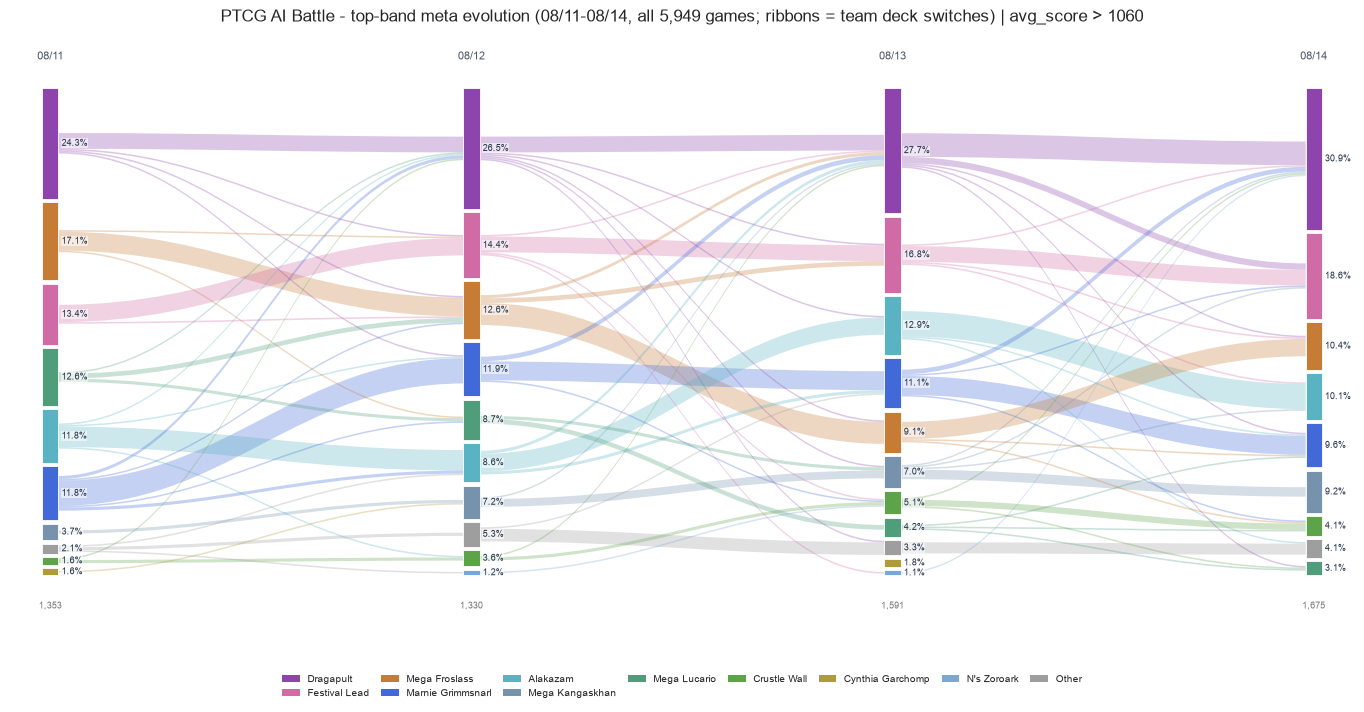

Average-score threshold: > 1060
All selected replays: 18,288
Filtered replays: 5,949
Saved: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend\analysis\archetype_sankey_avg_score_gt_1060.png


In [62]:
# Recompute the Sankey flow using only high-average-score replays.
SANKEY_MIN_AVG_SCORE = 1060.0

import io
import zipfile

replay_input_dir = Path(extract_cfg['input'])
if not replay_input_dir.is_absolute():
    replay_input_dir = (PROJECT_ROOT / replay_input_dir).resolve()

manifest_frames = []
for date_label in snapshot_dates:
    archive_path = replay_input_dir / f'{date_label}.zip'
    if not archive_path.is_file():
        raise FileNotFoundError(f'Replay archive not found: {archive_path}')
    with zipfile.ZipFile(archive_path) as replay_zip:
        if 'manifest.csv' not in replay_zip.namelist():
            raise FileNotFoundError(f'manifest.csv not found in {archive_path}')
        with replay_zip.open('manifest.csv') as raw:
            manifest = pd.read_csv(
                io.TextIOWrapper(raw, encoding='utf-8'),
                dtype={'episode_id': str},
                usecols=['episode_id', 'avg_score'],
            )
    manifest.insert(0, 'date', str(date_label))
    manifest_frames.append(manifest)

replay_scores = pd.concat(manifest_frames, ignore_index=True)
replay_scores['date'] = replay_scores['date'].astype(str)
replay_scores['episode_id'] = replay_scores['episode_id'].astype(str)
replay_scores['avg_score'] = pd.to_numeric(
    replay_scores['avg_score'], errors='raise'
)
if not np.isfinite(replay_scores['avg_score']).all():
    raise ValueError('manifest avg_score must be finite')
if replay_scores.duplicated(['date', 'episode_id']).any():
    raise ValueError('manifest contains duplicate date/episode_id rows')

annotated_for_score_join = annotated.copy()
annotated_for_score_join['date'] = annotated_for_score_join['date'].astype(str)
annotated_for_score_join['episode_id'] = (
    annotated_for_score_join['episode_id'].astype(str)
)
annotated_with_scores = annotated_for_score_join.merge(
    replay_scores,
    on=['date', 'episode_id'],
    how='left',
    validate='many_to_one',
)
if annotated_with_scores['avg_score'].isna().any():
    missing_scores = annotated_with_scores.loc[
        annotated_with_scores['avg_score'].isna(), ['date', 'episode_id']
    ].drop_duplicates()
    raise ValueError(
        f'Missing manifest scores for {len(missing_scores):,} replay(s)'
    )

score_sankey_rows = annotated_with_scores[
    annotated_with_scores['avg_score'] > SANKEY_MIN_AVG_SCORE
].copy()
if score_sankey_rows.empty:
    raise ValueError(
        f'No replay has avg_score > {SANKEY_MIN_AVG_SCORE:g}'
    )
score_pair_sizes = score_sankey_rows.groupby(['date', 'episode_id']).size()
assert score_pair_sizes.eq(2).all()
score_snapshot_dates = [
    date_label for date_label in snapshot_dates
    if date_label in set(score_sankey_rows['date'])
]

score_daily_metrics = build_daily_metrics(
    score_sankey_rows, exclude_mirrors=EXCLUDE_MIRROR_MATCHES
)
score_share_lookup = score_daily_metrics.set_index(
    ['date', 'archetype']
)['share_percent'].to_dict()
score_display_rows = score_sankey_rows[['date', 'archetype']].copy()
score_display_rows['display_archetype'] = score_display_rows.apply(
    lambda row: row['archetype']
    if score_share_lookup.get((row['date'], row['archetype']), 0)
    >= MIN_SHARE_PERCENT
    else 'Other',
    axis=1,
)
score_display_shares = (
    score_display_rows.groupby(
        ['date', 'display_archetype'], observed=True
    ).size().rename('uses').reset_index()
)
score_display_shares['share_percent'] = (
    100 * score_display_shares['uses']
    / score_display_shares.groupby('date', observed=True)['uses'].transform('sum')
)
score_team_modal = build_team_modal_archetypes(score_sankey_rows)
score_display_modal = score_team_modal.copy()
score_display_modal['display_archetype'] = score_display_modal.apply(
    lambda row: row['modal_archetype']
    if score_share_lookup.get((row['date'], row['modal_archetype']), 0)
    >= MIN_SHARE_PERCENT
    else 'Other',
    axis=1,
)
score_display_modal = score_display_modal.drop(
    columns='modal_archetype'
).rename(columns={'display_archetype': 'modal_archetype'})
score_display_flows, _ = build_team_flows(
    score_display_modal, score_snapshot_dates
)

score_sankey_figure = plot_archetype_sankey(
    score_display_shares, score_display_flows, score_snapshot_dates
)
score_sankey_figure.axes[0].set_title(
    score_sankey_figure.axes[0].get_title()
    + f' | avg_score > {SANKEY_MIN_AVG_SCORE:g}'
)
score_sankey_path = analysis_dir / (
    f'archetype_sankey_avg_score_gt_{SANKEY_MIN_AVG_SCORE:g}.png'
)
score_sankey_figure.savefig(
    score_sankey_path, dpi=180, bbox_inches='tight'
)
plt.show()
print(f'Average-score threshold: > {SANKEY_MIN_AVG_SCORE:g}')
print(f'All selected replays: {annotated_with_scores.episode_id.nunique():,}')
print(f'Filtered replays: {score_sankey_rows.episode_id.nunique():,}')
print('Saved:', score_sankey_path)

## Matchup Matrix

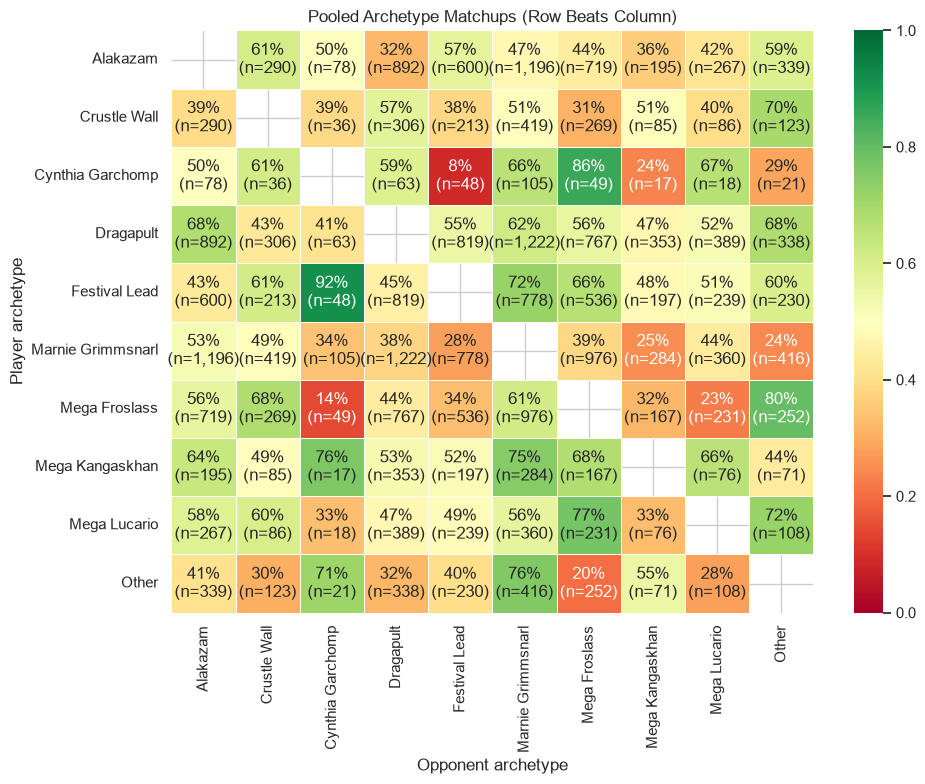

In [60]:
matchups = build_matchups(
    annotated, exclude_mirrors=EXCLUDE_MIRROR_MATCHES
)
assert (matchups['wins'] + matchups['losses'] + matchups['draws']).equals(
    matchups['games']
)
matchups.to_csv(
    analysis_dir / 'matchup_matrix_long.csv', index=False, encoding='utf-8-sig'
)
matrix_archetypes = sorted(
    set(matchups['row_archetype']) & global_visible_archetypes
)
matrix_rows = matchups[
    matchups['row_archetype'].isin(matrix_archetypes)
    & matchups['column_archetype'].isin(matrix_archetypes)
]
win_matrix = matrix_rows.pivot(
    index='row_archetype', columns='column_archetype', values='win_rate'
).reindex(index=matrix_archetypes, columns=matrix_archetypes)
game_matrix = matrix_rows.pivot(
    index='row_archetype', columns='column_archetype', values='games'
).reindex(index=matrix_archetypes, columns=matrix_archetypes)
annotations = win_matrix.copy().astype(object)
for row_name in matrix_archetypes:
    for column_name in matrix_archetypes:
        rate = win_matrix.loc[row_name, column_name]
        games = game_matrix.loc[row_name, column_name]
        annotations.loc[row_name, column_name] = (
            '' if pd.isna(rate) else f'{rate:.0%}\n(n={int(games):,})'
        )
plt.figure(figsize=(max(10, len(matrix_archetypes) * 0.85), max(8, len(matrix_archetypes) * 0.7)))
sns.heatmap(
    win_matrix, annot=annotations, fmt='', cmap='RdYlGn',
    vmin=0, vmax=1, center=0.5, linewidths=0.5,
)
plt.title('Pooled Archetype Matchups (Row Beats Column)')
plt.xlabel('Opponent archetype')
plt.ylabel('Player archetype')
plt.tight_layout()
plt.show()

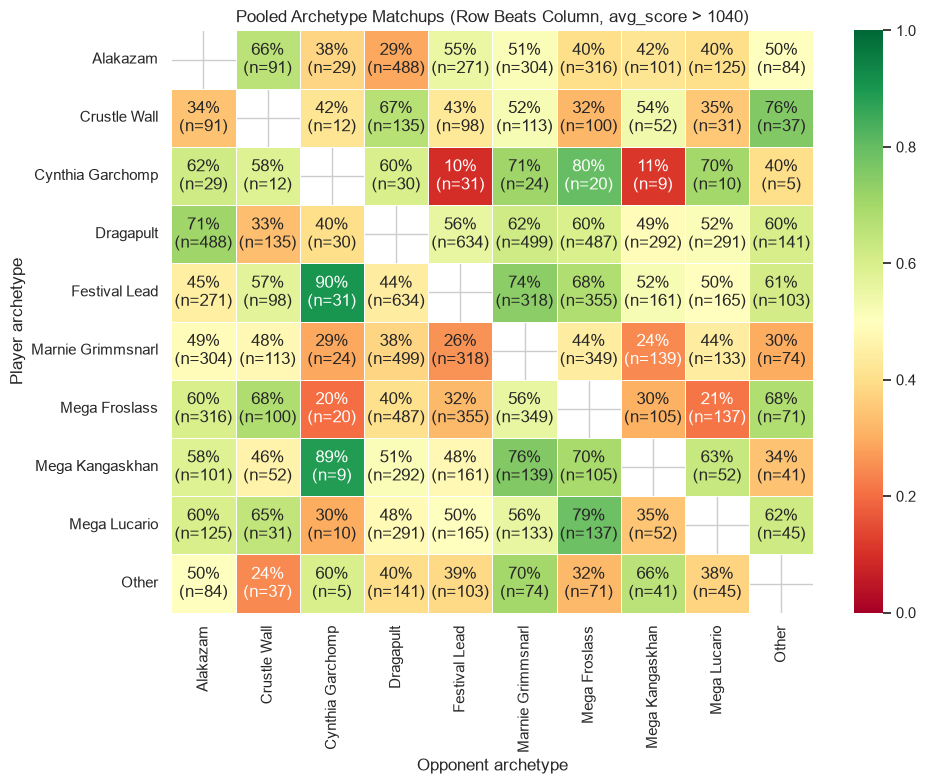

Average-score threshold: > 1040
All selected replays: 18,288
Filtered replays: 8,471
Saved: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend\analysis\matchup_matrix_avg_score_gt_1040_long.csv


In [63]:
# Recompute the matchup matrix using only high-average-score replays.
MATCHUP_MIN_AVG_SCORE = 1040.0

score_matchup_rows = annotated_with_scores[
    annotated_with_scores['avg_score'] > MATCHUP_MIN_AVG_SCORE
].copy()
if score_matchup_rows.empty:
    raise ValueError(
        f'No replay has avg_score > {MATCHUP_MIN_AVG_SCORE:g}'
    )
score_matchup_pair_sizes = score_matchup_rows.groupby(
    ['date', 'episode_id']
).size()
assert score_matchup_pair_sizes.eq(2).all()

score_matchups = build_matchups(
    score_matchup_rows, exclude_mirrors=EXCLUDE_MIRROR_MATCHES
)
assert (
    score_matchups['wins']
    + score_matchups['losses']
    + score_matchups['draws']
).equals(score_matchups['games'])
assert score_matchups['win_rate'].dropna().between(0, 1).all()
score_matchup_path = analysis_dir / (
    f'matchup_matrix_avg_score_gt_{MATCHUP_MIN_AVG_SCORE:g}_long.csv'
)
score_matchups.to_csv(
    score_matchup_path, index=False, encoding='utf-8-sig'
)
score_matrix_archetypes = sorted(
    set(score_matchups['row_archetype']) & global_visible_archetypes
)
if not score_matrix_archetypes:
    raise ValueError(
        'No score-filtered matchup remains after the archetype share filter'
    )
score_matrix_rows = score_matchups[
    score_matchups['row_archetype'].isin(score_matrix_archetypes)
    & score_matchups['column_archetype'].isin(score_matrix_archetypes)
]
score_win_matrix = score_matrix_rows.pivot(
    index='row_archetype', columns='column_archetype', values='win_rate'
).reindex(
    index=score_matrix_archetypes, columns=score_matrix_archetypes
)
score_game_matrix = score_matrix_rows.pivot(
    index='row_archetype', columns='column_archetype', values='games'
).reindex(
    index=score_matrix_archetypes, columns=score_matrix_archetypes
)
score_annotations = score_win_matrix.copy().astype(object)
for row_name in score_matrix_archetypes:
    for column_name in score_matrix_archetypes:
        rate = score_win_matrix.loc[row_name, column_name]
        games = score_game_matrix.loc[row_name, column_name]
        score_annotations.loc[row_name, column_name] = (
            '' if pd.isna(rate) else f'{rate:.0%}\n(n={int(games):,})'
        )
plt.figure(
    figsize=(
        max(10, len(score_matrix_archetypes) * 0.85),
        max(8, len(score_matrix_archetypes) * 0.7),
    )
)
sns.heatmap(
    score_win_matrix,
    annot=score_annotations,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    center=0.5,
    linewidths=0.5,
)
plt.title(
    'Pooled Archetype Matchups '
    f'(Row Beats Column, avg_score > {MATCHUP_MIN_AVG_SCORE:g})'
)
plt.xlabel('Opponent archetype')
plt.ylabel('Player archetype')
plt.tight_layout()
plt.show()
print(f'Average-score threshold: > {MATCHUP_MIN_AVG_SCORE:g}')
print(f'All selected replays: {annotated_with_scores.episode_id.nunique():,}')
print(f'Filtered replays: {score_matchup_rows.episode_id.nunique():,}')
print('Saved:', score_matchup_path)

## Exported Tables

In [57]:
exported = sorted(path.name for path in analysis_dir.glob('*.csv'))
print('Analysis output:', analysis_dir)
for name in exported:
    print('-', name)

Analysis output: d:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_trend\analysis
- archetype_daily_metrics.csv
- matchup_matrix_long.csv
- snapshot_dates.csv
- team_modal_archetypes.csv
- team_retention.csv
- team_snapshot_flows.csv


## Takeaways

After execution, review classification coverage before interpreting trends. A large `Other` share means the curated baseline needs more signature rules. Treat matchup rates with small displayed game counts as exploratory rather than stable estimates.